# Parcial 5: Evaluación de Modelos LLM con Ollama

**Estudiante:** [Tu Nombre]  
**Fecha:** 2025-11-23  
**Curso:** Ingeniería de Información

## Objetivos
1. Implementar y probar al menos 3 modelos LLM livianos
2. Realizar pruebas conversacionales
3. Generar informe de desempeño
4. Establecer conversación coherente con el mejor modelo

## Modelos Evaluados
- **llama3.2:1b** - Meta's Llama 3.2 (1B parámetros)
- **deepseek-r1:1.5b** - DeepSeek R1 (1.5B parámetros)
- **qwen2.5:0.5b** - Qwen 2.5 (500M parámetros)

## 1. Configuración Inicial

In [1]:
import subprocess
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [2]:
# Verificar instalación de Ollama
!ollama --version

ollama version is 0.12.3


In [3]:
# Listar modelos disponibles
!ollama list

NAME                ID              SIZE      MODIFIED          
qwen2.5:0.5b        a8b0c5157701    397 MB    About an hour ago    
deepseek-r1:1.5b    e0979632db5a    1.1 GB    About an hour ago    
llama3.2:1b         baf6a787fdff    1.3 GB    2 hours ago          
llama3.1:8b         46e0c10c039e    4.9 GB    2 weeks ago          


## 2. Funciones Auxiliares para Interacción con Modelos

In [11]:
def query_model(model_name: str, prompt: str, timeout: int = 120) -> Tuple[str, float]:
    """
    Consulta un modelo de Ollama usando su API HTTP y mide el tiempo de respuesta
    
    Args:
        model_name: Nombre del modelo
        prompt: Pregunta o instrucción
        timeout: Tiempo máximo de espera en segundos
    
    Returns:
        Tupla con (respuesta, tiempo_en_segundos)
    """
    import requests
    
    start_time = time.time()
    
    try:
        # Usar API de Ollama (más confiable que subprocess)
        url = "http://localhost:11434/api/generate"
        
        payload = {
            "model": model_name,
            "prompt": prompt,
            "stream": False
        }
        
        response = requests.post(url, json=payload, timeout=timeout)
        response.raise_for_status()
        
        elapsed_time = time.time() - start_time
        
        # Extraer la respuesta del JSON
        result = response.json()
        answer = result.get('response', '').strip()
        
        return answer, elapsed_time
    
    except requests.exceptions.Timeout:
        return "[TIMEOUT]", timeout
    except requests.exceptions.ConnectionError:
        return "[ERROR: No se pudo conectar a Ollama. ¿Está corriendo?]", 0
    except Exception as e:
        return f"[ERROR: {str(e)}]", 0


def display_response(model: str, prompt: str, response: str, time_taken: float):
    """Muestra de forma formateada la consulta y respuesta"""
    print("="*80)
    print(f"🤖 Modelo: {model}")
    print(f"⏱️  Tiempo: {time_taken:.2f}s")
    print("-"*80)
    print(f"❓ Pregunta: {prompt}")
    print("-"*80)
    print(f"💬 Respuesta:\n{response}")
    print("="*80 + "\n")

print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


## 3. Pruebas Conversacionales

In [12]:
# Definir prompts de prueba
test_prompts = [
    {"category": "Razonamiento Lógico", "prompt": "Si todos los perros ladran y Max es un perro, ¿qué podemos concluir sobre Max?"},
    {"category": "Matemáticas", "prompt": "Calcula: (15 + 25) × 2 - 10. Muestra el paso a paso."},
    {"category": "Creatividad", "prompt": "Escribe un poema corto de 4 versos sobre la inteligencia artificial."},
    {"category": "Programación", "prompt": "Escribe una función en Python que determine si un número es primo."},
    {"category": "Conocimiento General", "prompt": "¿Qué es el aprendizaje automático y cuál es su principal aplicación?"}
]

models = ["llama3.2:1b", "deepseek-r1:1.5b", "qwen2.5:0.5b"]

print(f"Total de pruebas: {len(models) * len(test_prompts)}")

Total de pruebas: 15


In [13]:
# Prueba rápida
test_model = "deepseek-r1:1.5b"
test_question = "¿Cuál es la capital de Francia?"

response, time_taken = query_model(test_model, test_question)
display_response(test_model, test_question, response, time_taken)

🤖 Modelo: deepseek-r1:1.5b
⏱️  Tiempo: 32.50s
--------------------------------------------------------------------------------
❓ Pregunta: ¿Cuál es la capital de Francia?
--------------------------------------------------------------------------------
💬 Respuesta:
<think>
Okay, so I need to figure out the capital of France. I remember that France is a country in Europe, but I'm not exactly sure about its political structure or government system. Wait, isn't it something called a republic? Yeah, France has a republic model where there's a prime minister and a parliament instead of the president and a government office.

I think the capital of a republic is usually the place where their flag is displayed, but I'm not sure about that. Maybe it's another city or a village. Let me try to recall. I believe the Eiffel Tower is a big landmark around Paris, so maybe Paris itself is the capital? That makes sense because capitals are often named after cities they're in.

I remember learning that 

In [14]:
# Ejecutar todas las pruebas
results = []

for test in test_prompts:
    for model in models:
        print(f"Consultando {model} - {test['category']}...")
        response, time_taken = query_model(model, test['prompt'])
        
        results.append({
            'model': model,
            'category': test['category'],
            'prompt': test['prompt'],
            'response': response,
            'time': time_taken,
            'response_length': len(response),
            'success': not response.startswith('[ERROR') and not response.startswith('[TIMEOUT')
        })
        time.sleep(1)

df_results = pd.DataFrame(results)
print(f"\nPruebas completadas: {len(df_results)}")

Consultando llama3.2:1b - Razonamiento Lógico...
Consultando deepseek-r1:1.5b - Razonamiento Lógico...
Consultando qwen2.5:0.5b - Razonamiento Lógico...
Consultando llama3.2:1b - Matemáticas...
Consultando deepseek-r1:1.5b - Matemáticas...
Consultando qwen2.5:0.5b - Matemáticas...
Consultando llama3.2:1b - Creatividad...
Consultando deepseek-r1:1.5b - Creatividad...
Consultando qwen2.5:0.5b - Creatividad...
Consultando llama3.2:1b - Programación...
Consultando deepseek-r1:1.5b - Programación...
Consultando qwen2.5:0.5b - Programación...
Consultando llama3.2:1b - Conocimiento General...
Consultando deepseek-r1:1.5b - Conocimiento General...
Consultando qwen2.5:0.5b - Conocimiento General...

Pruebas completadas: 15


## 4. Análisis de Desempeño

In [15]:
# Resumen estadístico
summary = df_results.groupby('model').agg({
    'time': ['mean', 'median', 'min', 'max'],
    'response_length': 'mean',
    'success': 'mean'
}).round(2)

print(summary)

                   time                      response_length success
                   mean median    min    max            mean    mean
model                                                               
deepseek-r1:1.5b  59.31  38.07  28.17  96.60          3034.0     1.0
llama3.2:1b       19.20  16.03   4.85  36.93           738.2     1.0
qwen2.5:0.5b      12.46  14.62   3.82  23.19          1042.6     1.0


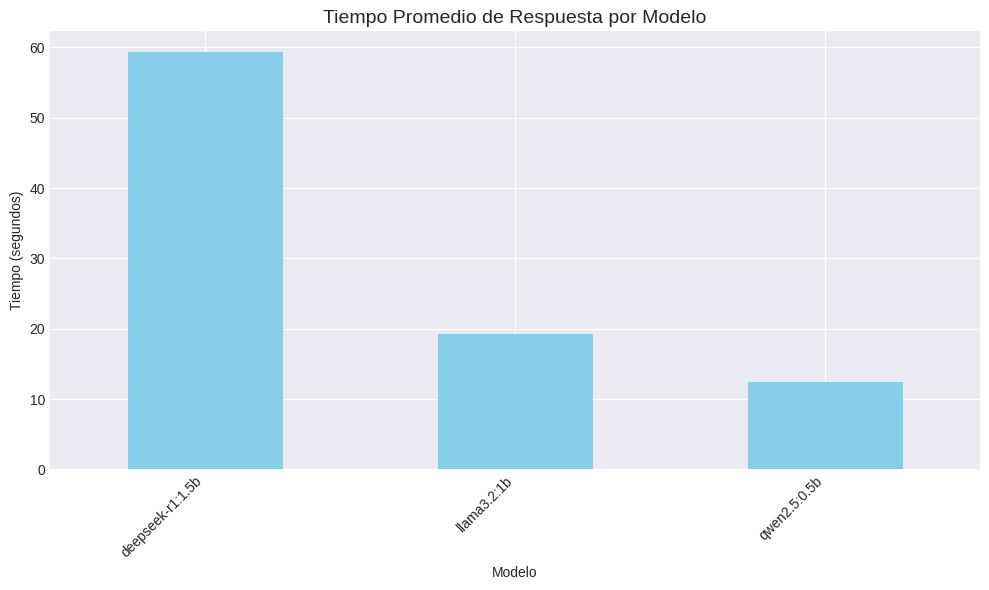

In [17]:
# Visualización - Tiempo promedio
fig, ax = plt.subplots(figsize=(10, 6))
df_results.groupby('model')['time'].mean().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Tiempo Promedio de Respuesta por Modelo', fontsize=14)
ax.set_ylabel('Tiempo (segundos)')
ax.set_xlabel('Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Determinar mejor modelo
model_scores = df_results.groupby('model').agg({'time': 'mean', 'success': 'mean'})
model_scores['time_score'] = 1 - (model_scores['time'] - model_scores['time'].min()) / (model_scores['time'].max() - model_scores['time'].min())
model_scores['overall_score'] = (model_scores['time_score'] * 0.5 + model_scores['success'] * 0.5)
best_model = model_scores['overall_score'].idxmax()

print(f"🏆 MEJOR MODELO: {best_model}")
print(model_scores)

🏆 MEJOR MODELO: qwen2.5:0.5b
                       time  success  time_score  overall_score
model                                                          
deepseek-r1:1.5b  59.306771      1.0    0.000000       0.500000
llama3.2:1b       19.201381      1.0    0.856111       0.928056
qwen2.5:0.5b      12.460775      1.0    1.000000       1.000000


## 5. Conversación con Mejor Modelo

In [19]:
conversation_prompts = [
    "Hola, ¿cómo estás?",
    "¿Cuáles son las aplicaciones de la IA?",
    "¿Y los desafíos éticos?",
    "¿Cómo desarrollar IA responsable?",
    "Recomendación final sobre el futuro de la IA"
]

conversation_log = []
for i, prompt in enumerate(conversation_prompts, 1):
    response, time_taken = query_model(best_model, prompt)
    conversation_log.append({'turn': i, 'user': prompt, 'assistant': response, 'time': time_taken})
    display_response(best_model, prompt, response, time_taken)
    time.sleep(2)

🤖 Modelo: qwen2.5:0.5b
⏱️  Tiempo: 1.16s
--------------------------------------------------------------------------------
❓ Pregunta: Hola, ¿cómo estás?
--------------------------------------------------------------------------------
💬 Respuesta:
Hola! Estoy bien, gracias por preguntar. ¿Cómo te sientes hoy?

🤖 Modelo: qwen2.5:0.5b
⏱️  Tiempo: 19.84s
--------------------------------------------------------------------------------
❓ Pregunta: ¿Cuáles son las aplicaciones de la IA?
--------------------------------------------------------------------------------
💬 Respuesta:
La IA (Intelligence Agentia) está en constante evolución y se extiende a diversos campos y sectores. Aquí te presento algunas aplicaciones de la IA:

1. Textos: Utiliza algoritmos para analizar, comprender y generar textos, como el modelo de Hugging Face Transformers.

2. Lenguaje Natural: Aplica en procesamiento de texto corporal, aprendizaje automático de lenguaje natural (NLP), etc.

3. Visualización: Manejo de imá

## 6. Exportar Resultados

In [20]:
import os
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

df_results.to_csv(f'{results_dir}/detailed_results.csv', index=False)
with open(f'{results_dir}/best_model_conversation.json', 'w', encoding='utf-8') as f:
    json.dump({'model': best_model, 'timestamp': datetime.now().isoformat(), 'conversation': conversation_log}, f, indent=2, ensure_ascii=False)

summary.to_csv(f'{results_dir}/performance_summary.csv')
print("✓ Resultados exportados")

✓ Resultados exportados
